# VIX Spike Prediction Workflow

This notebook is the clean driver notebook for the modular `vix_fomc_pkg` package. It keeps the workflow readable:

1. Environment setup
2. FOMC statement features
3. Optional FinBERT / attention embeddings
4. Daily market master table
5. VIX 10-day spike target
6. Chronological train/validation/test split
7. Baseline and XGBoost models
8. Optional LSTM model
9. Error analysis and saved outputs

The recommended workflow is to run the tabular baseline/XGBoost first. The LSTM section is included for comparison, but it is intentionally treated as optional.

## 0. Setup

Place this notebook in the same folder as `vix_fomc_pkg.zip`, or keep the extracted `vix_fomc_pkg/` folder next to this notebook.

In [300]:
from google.colab import drive
import os, random
import numpy as np
import torch
drive.mount('/content/drive')
%cd /content/drive/MyDrive/OMSCS/Deep_Learning/Final_Project/Code/
!ls

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("You are using device: %s" % device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/OMSCS/Deep_Learning/Final_Project/Code
cache		       simple_baselines.ipynb  vix_fomc_workflow.ipynb
fomc_token_embeddings  vix_fomc_pkg
outputs		       vix_fomc_pkg.zip
You are using device: cpu


In [2]:
# Optional installs. Run only if your environment is missing these packages.
!pip install yfinance xgboost scikit-learn pandas numpy matplotlib requests beautifulsoup4
# Optional heavy NLP dependencies:
!pip install torch transformers pytrends

In [3]:
from pathlib import Path
import zipfile
import warnings
warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()
PKG_ZIP = PROJECT_DIR / "vix_fomc_pkg.zip"
PKG_DIR = PROJECT_DIR / "vix_fomc_pkg"

# If only the zip exists, extract it.
if (not PKG_DIR.exists()) and PKG_ZIP.exists():
    with zipfile.ZipFile(PKG_ZIP, "r") as zf:
        zf.extractall(PROJECT_DIR)

assert PKG_DIR.exists(), "vix_fomc_pkg folder not found. Put vix_fomc_pkg.zip or extracted vix_fomc_pkg/ next to this notebook."

In [301]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vix_fomc_pkg import *

set_seed(42)
device = get_torch_device()
print("Device:", device)

Device: None


## 1. Global parameters

Use a fixed date range so all data sources align. `TRAIN_FRAC=0.80` and `VAL_FRAC=0.10` reproduce your earlier chronological split style.

In [262]:
START_DATE = "2006-01-01"
END_DATE = "2026-04-30"
DAILY_DATES = pd.bdate_range(START_DATE, END_DATE)

SPIKE_WINDOW = 10
SPIKE_QUANTILE = 0.75 #0.85
TARGET_COL = f"target_vix_spike_{SPIKE_WINDOW}d"

TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
SEQ_LEN = 60
BATCH_SIZE = 64

CACHE_DIR = PROJECT_DIR / "cache"
CACHE_DIR.mkdir(exist_ok=True)

## 2. Build FOMC statement features

This step fetches FOMC statements, cleans the text, and creates simple lexicon features. The output is event-level: one row per FOMC meeting.

If you already cached the file, the notebook loads it instead of refetching.

In [6]:
fomc_cache = CACHE_DIR / "fomc_lexicon_features.parquet"

if fomc_cache.exists():
    fomc_df = pd.read_parquet(fomc_cache)
else:
    fomc_df = build_fomc_dataframe(sleep_sec=0.2, verbose=True)
    fomc_df = add_clean_text(fomc_df)
    fomc_df = add_lexicon_features(fomc_df)
    fomc_df.to_parquet(fomc_cache)

print(fomc_df.shape)
fomc_df.tail()

(164, 11)


,is_sep,raw_text,clean_text,text_length,hawkish_score,dovish_score,uncertainty_score,inflation_score,labor_score,policy_decision,policy_encoded
date,,,,,,,,,,,
2025-09-17,True,Recent indicators suggest that growth of econo...,Recent indicators suggest that growth of econo...,264,0.000000,0.007576,0.018939,0.026515,0.034091,hike,1
2025-10-29,False,Available indicators suggest that economic act...,Available indicators suggest that economic act...,278,0.000000,0.007194,0.017986,0.025180,0.032374,hike,1
2025-12-10,True,Available indicators suggest that economic act...,Available indicators suggest that economic act...,297,0.000000,0.006734,0.016835,0.023569,0.030303,hike,1
2026-01-28,False,Available indicators suggest that economic act...,Available indicators suggest that economic act...,222,0.004505,0.000000,0.018018,0.031532,0.036036,hike,1
2026-03-18,True,Available indicators suggest that economic act...,Available indicators suggest that economic act...,237,0.004219,0.000000,0.016878,0.029536,0.033755,hike,1


In [7]:
# Quick sanity checks
feature_preview_cols = [
    "text_length", "hawkish_score", "dovish_score", "uncertainty_score",
    "inflation_score", "labor_score", "policy_decision", "policy_encoded", "is_sep"
]
existing_preview_cols = [c for c in feature_preview_cols if c in fomc_df.columns]
fomc_df[existing_preview_cols].tail(10)

,text_length,hawkish_score,dovish_score,uncertainty_score,inflation_score,labor_score,policy_decision,policy_encoded,is_sep
date,,,,,,,,,
2025-01-29,259,0.003861,0.000000,0.015444,0.030888,0.030888,hike,1,False
2025-03-19,291,0.003436,0.003436,0.013746,0.024055,0.024055,hike,1,True
2025-05-07,266,0.003759,0.000000,0.018797,0.030075,0.030075,hike,1,False
2025-06-18,248,0.004032,0.000000,0.016129,0.028226,0.028226,hike,1,True
2025-07-30,248,0.004032,0.000000,0.016129,0.028226,0.028226,hike,1,False
2025-09-17,264,0.000000,0.007576,0.018939,0.026515,0.034091,hike,1,True
2025-10-29,278,0.000000,0.007194,0.017986,0.025180,0.032374,hike,1,False
2025-12-10,297,0.000000,0.006734,0.016835,0.023569,0.030303,hike,1,True
2026-01-28,222,0.004505,0.000000,0.018018,0.031532,0.036036,hike,1,False


## 3. Optional: FinBERT statement embeddings

Run this only if you want statement-level semantic embeddings. This can take time and requires `transformers` + `torch`.

For a cleaner first pass, you can skip this and go directly to Section 5.

In [8]:
RUN_FINBERT = True

finbert_cache = CACHE_DIR / "fomc_finbert_features.parquet"

if RUN_FINBERT:
    if finbert_cache.exists():
        fomc_df = pd.read_parquet(finbert_cache)
    else:
        fomc_df = add_finbert_embedding_features(
            fomc_df,
            text_col="clean_text",
            n_components=8,
        )
        fomc_df.to_parquet(finbert_cache)

print(fomc_df.shape)
[c for c in fomc_df.columns if "pca" in c or "cosine" in c or "language_shift" in c][:20]

(164, 30)


['cosine_change_from_prev',
 'language_shift',
 'stmt_pca_1',
 'change_pca_1',
 'stmt_pca_2',
 'change_pca_2',
 'stmt_pca_3',
 'change_pca_3',
 'stmt_pca_4',
 'change_pca_4',
 'stmt_pca_5',
 'change_pca_5',
 'stmt_pca_6',
 'change_pca_6',
 'stmt_pca_7',
 'change_pca_7',
 'stmt_pca_8',
 'change_pca_8']

## 4. Optional: token-level FOMC attention embeddings

This reproduces the more complex FOMC token-attention idea. It is optional and should not be the first model you rely on. It requires saved token embeddings.

The output columns are `stmt_attn_1`, `stmt_attn_2`, ..., which can be forward-filled into the daily feature table.

In [9]:
RUN_TOKEN_ATTENTION = True
TOKEN_EMB_DIR = PROJECT_DIR / "fomc_token_embeddings"
attn_cache = CACHE_DIR / "fomc_attention_features.parquet"

if RUN_TOKEN_ATTENTION:
    # 1. Save token embeddings if needed.
    #    This step requires FinBERT and can be slow.
    if not TOKEN_EMB_DIR.exists():
        save_token_embeddings(
            fomc_df,
            out_dir=TOKEN_EMB_DIR,
            text_col="clean_text",
            max_length=128,
        )

    # 2. Download VIX first because the event-level target needs VIX.
    vix_for_attn = download_yfinance_close("^VIX", start=START_DATE, end=END_DATE, name="^VIX")

    # 3. Build event-level regression target.
    target_df = build_fomc_attention_targets(
        fomc_df,
        vix_for_attn,
        horizon=SPIKE_WINDOW,
        emb_dir=TOKEN_EMB_DIR,
        target_col="fomc_target_10d",
    )
    target_df["fomc_target_10d_scaled"] = (
        target_df["fomc_target_10d"] - target_df["fomc_target_10d"].mean()
    ) / target_df["fomc_target_10d"].std()

    # 4. Event-level chronological split.
    dates = target_df.index
    n = len(dates)
    train_dates_attn = dates[: int(n * 0.75)]
    val_dates_attn = dates[int(n * 0.75) : int(n * 0.90)]

    import torch
    from torch.utils.data import DataLoader

    FOMCDataset = make_fomc_token_dataset_class()
    train_ds = FOMCDataset(train_dates_attn, target_df, emb_dir=TOKEN_EMB_DIR)
    val_ds = FOMCDataset(val_dates_attn, target_df, emb_dir=TOKEN_EMB_DIR)
    train_loader_attn = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader_attn = DataLoader(val_ds, batch_size=16, shuffle=False)

    FOMCAttnModel = make_fomc_attention_model_class()
    attn_model = FOMCAttnModel(token_dim=768, hidden_dim=128, proj_dim=48, dropout=0.20)
    attn_model, attn_history = train_fomc_attention_model(
        attn_model,
        train_loader_attn,
        val_loader_attn,
        epochs=300,
        patience=30,
        lr=1e-4,
    )

    attn_features = extract_attention_embeddings(
      attn_model,
      fomc_df.index,
      emb_dir=TOKEN_EMB_DIR,
      proj_dim=48,
      device=device,
    )

    fomc_df = fomc_df.join(attn_features, how="left")
    fomc_df.to_parquet(attn_cache)

elif attn_cache.exists():
    # Load previously created attention features.
    fomc_df = pd.read_parquet(attn_cache)

print(fomc_df.shape)
[c for c in fomc_df.columns if c.startswith("stmt_attn_")][:10]

[*********************100%***********************]  1 of 1 completed


Epoch 001 | Train Loss: 0.29687 | Val Loss: 0.30210
Epoch 002 | Train Loss: 0.26895 | Val Loss: 0.28848
Epoch 003 | Train Loss: 0.25606 | Val Loss: 0.28060
Epoch 004 | Train Loss: 0.26210 | Val Loss: 0.27837
Epoch 005 | Train Loss: 0.26255 | Val Loss: 0.28037
Epoch 006 | Train Loss: 0.26321 | Val Loss: 0.28033
Epoch 007 | Train Loss: 0.26134 | Val Loss: 0.28011
Epoch 008 | Train Loss: 0.25506 | Val Loss: 0.28153
Epoch 009 | Train Loss: 0.25562 | Val Loss: 0.28544
Epoch 010 | Train Loss: 0.24906 | Val Loss: 0.27836
Epoch 011 | Train Loss: 0.25778 | Val Loss: 0.27650
Epoch 012 | Train Loss: 0.25719 | Val Loss: 0.28513
Epoch 013 | Train Loss: 0.24993 | Val Loss: 0.29414
Epoch 014 | Train Loss: 0.25185 | Val Loss: 0.29580
Epoch 015 | Train Loss: 0.23982 | Val Loss: 0.29406
Epoch 016 | Train Loss: 0.24591 | Val Loss: 0.29254
Epoch 017 | Train Loss: 0.24565 | Val Loss: 0.31766
Epoch 018 | Train Loss: 0.23436 | Val Loss: 0.30290
Epoch 019 | Train Loss: 0.23788 | Val Loss: 0.30330
Epoch 020 | 

['stmt_attn_1',
 'stmt_attn_2',
 'stmt_attn_3',
 'stmt_attn_4',
 'stmt_attn_5',
 'stmt_attn_6',
 'stmt_attn_7',
 'stmt_attn_8',
 'stmt_attn_9',
 'stmt_attn_10']

## 5. Build daily FOMC feature table

This converts event-level FOMC features into business-day features by forward-filling the latest available statement features.

Important: these features only change on FOMC dates, so do not overinterpret them as daily high-frequency signals.

In [10]:
daily_fomc = build_daily_fomc_features(
    daily_dates=DAILY_DATES,
    fomc_df=fomc_df,
    attn_proj_dim=48,
)

print(daily_fomc.shape)
daily_fomc.tail()

(5304, 61)


,is_fomc_day,days_since_last_fomc,days_to_next_fomc,hawkish_score,dovish_score,uncertainty_score,inflation_score,labor_score,policy_encoded,text_length,...,stmt_attn_39,stmt_attn_40,stmt_attn_41,stmt_attn_42,stmt_attn_43,stmt_attn_44,stmt_attn_45,stmt_attn_46,stmt_attn_47,stmt_attn_48
date,,,,,,,,,,,,,,,,,,,,,
2026-04-24,0,37.0,NaN,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,1.196106,0.0,0.492256,0.0,0.802925,0.0,0.0,1.704974,1.001368,0.407324
2026-04-27,0,40.0,NaN,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,1.196106,0.0,0.492256,0.0,0.802925,0.0,0.0,1.704974,1.001368,0.407324
2026-04-28,0,41.0,NaN,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,1.196106,0.0,0.492256,0.0,0.802925,0.0,0.0,1.704974,1.001368,0.407324
2026-04-29,0,42.0,NaN,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,1.196106,0.0,0.492256,0.0,0.802925,0.0,0.0,1.704974,1.001368,0.407324
2026-04-30,0,43.0,NaN,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,1.196106,0.0,0.492256,0.0,0.802925,0.0,0.0,1.704974,1.001368,0.407324


## 6. Optional: Google Trends

Google Trends can be added as auxiliary data, but for VIX spike prediction it should be treated as secondary.

In [11]:
RUN_GOOGLE_TRENDS = True
trends_daily = None

if RUN_GOOGLE_TRENDS:
    trends_cache = CACHE_DIR / "google_trends_daily.parquet"
    if trends_cache.exists():
        trends_daily = pd.read_parquet(trends_cache)
    else:
        trends_weekly = fetch_google_trends(
            ["recession", "inflation", "stock market crash", "interest rates"],
            start=START_DATE,
            end=END_DATE,
            geo="US",
        )
        trends_daily = trends_weekly_to_daily(trends_weekly, DAILY_DATES)
        trends_daily.to_parquet(trends_cache)

if trends_daily is not None:
    print(trends_daily.shape)
    display(trends_daily.tail())
else:
    print("Google Trends skipped.")

(5304, 4)


,trend_recession,trend_inflation,trend_stock_market_crash,trend_interest_rates
2026-04-24,16.0,68.0,4.0,50.0
2026-04-27,16.0,68.0,4.0,50.0
2026-04-28,16.0,68.0,4.0,50.0
2026-04-29,16.0,68.0,4.0,50.0
2026-04-30,16.0,68.0,4.0,50.0


## 7. Market data and master dataset

This downloads VIX and merges it with FOMC features. You can add stronger market-implied features later through `extra_features`.

In [12]:
vix_cache = CACHE_DIR / "vix.parquet"

if vix_cache.exists():
    vix = pd.read_parquet(vix_cache)["^VIX"]
else:
    vix = download_yfinance_close("^VIX", start=START_DATE, end=END_DATE, name="^VIX")
    vix.to_frame().to_parquet(vix_cache)

print(vix.shape)
vix.tail()

[*********************100%***********************]  1 of 1 completed

(5112,)


,^VIX
Date,
2026-04-23,19.309999
2026-04-24,18.709999
2026-04-27,18.020000
2026-04-28,17.830000
2026-04-29,18.809999


In [13]:
# Optional placeholder for stronger market data later.
# Examples: VIX9D, VIX3M, VVIX, SKEW, SPY returns, credit spreads, NFCI, MOVE.
extra_features = None

master = build_master_dataset(
    daily_fomc=daily_fomc,
    vix=vix,
    google_trends_daily=trends_daily,
    extra_features=extra_features,
    ffill=True,
)

print(master.shape)
master.tail()

(5304, 66)


,is_fomc_day,days_since_last_fomc,days_to_next_fomc,hawkish_score,dovish_score,uncertainty_score,inflation_score,labor_score,policy_encoded,text_length,...,stmt_attn_44,stmt_attn_45,stmt_attn_46,stmt_attn_47,stmt_attn_48,^VIX,trend_recession,trend_inflation,trend_stock_market_crash,trend_interest_rates
date,,,,,,,,,,,,,,,,,,,,,
2026-04-24,0,37.0,1.0,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,0.0,0.0,1.704974,1.001368,0.407324,18.709999,16.0,68.0,4.0,50.0
2026-04-27,0,40.0,1.0,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,0.0,0.0,1.704974,1.001368,0.407324,18.020000,16.0,68.0,4.0,50.0
2026-04-28,0,41.0,1.0,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,0.0,0.0,1.704974,1.001368,0.407324,17.830000,16.0,68.0,4.0,50.0
2026-04-29,0,42.0,1.0,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,0.0,0.0,1.704974,1.001368,0.407324,18.809999,16.0,68.0,4.0,50.0
2026-04-30,0,43.0,1.0,0.004219,0.0,0.016878,0.029536,0.033755,1.0,237.0,...,0.0,0.0,1.704974,1.001368,0.407324,18.809999,16.0,68.0,4.0,50.0


## 8. Create 10-day VIX spike target

This uses the future maximum VIX over the next 10 trading days. The threshold is fitted on the training period only to avoid threshold leakage.

In [263]:
# First make preliminary dates from the available master index.
prelim_train_dates, prelim_val_dates, prelim_test_dates = make_time_splits(
    master.dropna().index,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
)
train_end_for_threshold = prelim_train_dates[-1]
print("Train-end used for threshold:", train_end_for_threshold)

master, spike_threshold = add_vix_spike_target(
    master,
    vix_col="^VIX",
    window=SPIKE_WINDOW,
    quantile=SPIKE_QUANTILE,
    target_col=TARGET_COL,
    train_end=train_end_for_threshold,
)

print("Spike threshold:", spike_threshold)
print(master.shape)
master[["^VIX", f"vix_future_max_{SPIKE_WINDOW}d_change", TARGET_COL]].tail()

Train-end used for threshold: 2018-03-08 00:00:00
Spike threshold: 0.18696885268788122
(5273, 68)


,^VIX,vix_future_max_10d_change,target_vix_spike_10d
date,,,
2026-03-13,27.190001,0.132750,0
2026-03-16,23.510000,0.278173,1
2026-03-17,22.370001,0.327878,1
2026-03-18,25.090000,0.213129,1
2026-03-19,24.059999,0.255048,1


In [264]:
# Target distribution by chronological split after target construction.
X_df_tmp, y_tmp = prepare_tabular_features(master, target_col=TARGET_COL)
train_dates, val_dates, test_dates = make_time_splits(X_df_tmp.index, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

for name, dates in [("train", train_dates), ("val", val_dates), ("test", test_dates)]:
    y_part = y_tmp.loc[dates]
    print(name, "date range:", dates[0], "to", dates[-1], "n=", len(y_part), "positive_rate=", round(y_part.mean(), 4), "pos=", int(y_part.sum()))

train date range: 2006-02-01 00:00:00 to 2018-02-28 00:00:00 n= 3151 positive_rate= 0.2491 pos= 785
val date range: 2018-03-01 00:00:00 to 2022-03-09 00:00:00 n= 1050 positive_rate= 0.3219 pos= 338
test date range: 2022-03-10 00:00:00 to 2026-03-19 00:00:00 n= 1051 positive_rate= 0.2636 pos= 277


## 9. Prepare tabular features

This removes the target and leakage columns, keeps numeric/bool features, then scales features using train-only statistics.

In [265]:
X_df, y = prepare_tabular_features(master, target_col=TARGET_COL)
train_dates, val_dates, test_dates = make_time_splits(X_df.index, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

X_scaled, scaler_X = scale_features_train_only(X_df, train_dates)

X_train_tab = X_scaled.loc[train_dates].values
X_val_tab = X_scaled.loc[val_dates].values
X_test_tab = X_scaled.loc[test_dates].values

y_train_tab = y.loc[train_dates].values
y_val_tab = y.loc[val_dates].values
y_test_tab = y.loc[test_dates].values

print("Feature count:", X_scaled.shape[1])
print("Train/val/test:", X_train_tab.shape, X_val_tab.shape, X_test_tab.shape)

Feature count: 66
Train/val/test: (3151, 66) (1050, 66) (1051, 66)


In [266]:
X_df.columns.tolist()

['is_fomc_day',
 'days_since_last_fomc',
 'days_to_next_fomc',
 'hawkish_score',
 'dovish_score',
 'uncertainty_score',
 'inflation_score',
 'labor_score',
 'policy_encoded',
 'text_length',
 'cosine_change_from_prev',
 'language_shift',
 'is_sep',
 'stmt_attn_1',
 'stmt_attn_2',
 'stmt_attn_3',
 'stmt_attn_4',
 'stmt_attn_5',
 'stmt_attn_6',
 'stmt_attn_7',
 'stmt_attn_8',
 'stmt_attn_9',
 'stmt_attn_10',
 'stmt_attn_11',
 'stmt_attn_12',
 'stmt_attn_13',
 'stmt_attn_14',
 'stmt_attn_15',
 'stmt_attn_16',
 'stmt_attn_17',
 'stmt_attn_18',
 'stmt_attn_19',
 'stmt_attn_20',
 'stmt_attn_21',
 'stmt_attn_22',
 'stmt_attn_23',
 'stmt_attn_24',
 'stmt_attn_25',
 'stmt_attn_26',
 'stmt_attn_27',
 'stmt_attn_28',
 'stmt_attn_29',
 'stmt_attn_30',
 'stmt_attn_31',
 'stmt_attn_32',
 'stmt_attn_33',
 'stmt_attn_34',
 'stmt_attn_35',
 'stmt_attn_36',
 'stmt_attn_37',
 'stmt_attn_38',
 'stmt_attn_39',
 'stmt_attn_40',
 'stmt_attn_41',
 'stmt_attn_42',
 'stmt_attn_43',
 'stmt_attn_44',
 'stmt_attn_

## 10. Baseline metrics

Always compare against trivial baselines. For imbalanced spike classification, PR-AUC should be interpreted relative to the base positive rate.

In [267]:
baseline_df = evaluate_baselines(y_train_tab, y_val_tab, y_test_tab)
baseline_df[["model", "split", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "positive_rate_true", "positive_rate_pred"]]

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate_true,positive_rate_pred
0,always_zero,val,0.678095,0.000000,0.0,0.000000,0.5,0.321905,0.321905,0.0
1,always_zero,test,0.736441,0.000000,0.0,0.000000,0.5,0.263559,0.263559,0.0
2,always_one,val,0.321905,0.321905,1.0,0.487032,0.5,0.321905,0.321905,1.0
3,always_one,test,0.263559,0.263559,1.0,0.417169,0.5,0.263559,0.263559,1.0
4,train_base_rate,val,0.678095,0.000000,0.0,0.000000,0.5,0.321905,0.321905,0.0
5,train_base_rate,test,0.736441,0.000000,0.0,0.000000,0.5,0.263559,0.263559,0.0


## 11. XGBoost tabular model

This is the recommended first serious model. It uses today’s engineered daily state instead of a 60-day raw sequence.

In [268]:
RUN_XGBOOST = True

if RUN_XGBOOST:
    xgb_model = train_xgboost_classifier(
        X_train_tab,
        y_train_tab,
        X_val_tab,
        y_val_tab,
        num_boost_round=1000,
        early_stopping_rounds=30,
        verbose_eval=25,
    )

    val_xgb_metrics_05 = evaluate_xgboost_classifier(xgb_model, X_val_tab, y_val_tab, threshold=0.5)
    test_xgb_metrics_05 = evaluate_xgboost_classifier(xgb_model, X_test_tab, y_test_tab, threshold=0.5)

    print_metrics("XGBoost Validation @ 0.50", val_xgb_metrics_05)
    print_metrics("XGBoost Test @ 0.50", test_xgb_metrics_05)

[0]	train-aucpr:0.32089	val-aucpr:0.34537
[25]	train-aucpr:0.50246	val-aucpr:0.34846
[50]	train-aucpr:0.56025	val-aucpr:0.35508
[75]	train-aucpr:0.59536	val-aucpr:0.35291
[79]	train-aucpr:0.60214	val-aucpr:0.35681

XGBoost Validation @ 0.50
threshold: 0.5000
accuracy: 0.5552
precision: 0.3636
recall: 0.5089
f1: 0.4242
roc_auc: 0.5449
pr_auc: 0.3619
positive_rate_true: 0.3219
positive_rate_pred: 0.4505
Confusion matrix:
[[411 301]
 [166 172]]

XGBoost Test @ 0.50
threshold: 0.5000
accuracy: 0.4615
precision: 0.2780
recall: 0.6534
f1: 0.3901
roc_auc: 0.5406
pr_auc: 0.3368
positive_rate_true: 0.2636
positive_rate_pred: 0.6194
Confusion matrix:
[[304 470]
 [ 96 181]]


In [269]:
if RUN_XGBOOST:
    import xgboost as xgb

    val_prob_xgb = xgb_model.predict(xgb.DMatrix(X_val_tab))
    test_prob_xgb = xgb_model.predict(xgb.DMatrix(X_test_tab))

    best_t, best_val_metrics = find_best_threshold_by_f1_limited_alert_rate(
        y_val_tab,
        val_prob_xgb,
        max_alert_rate=0.30,
    )
    test_metrics_best_t = binary_metrics(y_test_tab, test_prob_xgb, threshold=best_t)

    print_metrics("XGBoost Validation @ selected threshold", best_val_metrics)
    print_metrics("XGBoost Test @ selected threshold", test_metrics_best_t)


XGBoost Validation @ selected threshold
threshold: 0.5300
accuracy: 0.6133
precision: 0.3768
recall: 0.3077
f1: 0.3388
roc_auc: 0.5449
pr_auc: 0.3619
positive_rate_true: 0.3219
positive_rate_pred: 0.2629
Confusion matrix:
[[540 172]
 [234 104]]

XGBoost Test @ selected threshold
threshold: 0.5300
accuracy: 0.5071
precision: 0.2722
recall: 0.5199
f1: 0.3573
roc_auc: 0.5406
pr_auc: 0.3368
positive_rate_true: 0.2636
positive_rate_pred: 0.5033
Confusion matrix:
[[389 385]
 [133 144]]


In [270]:

# Feature importance by gain.
importance = xgb_model.get_score(importance_type="gain")
importance_df = (
    pd.DataFrame({"feature": list(importance.keys()), "gain": list(importance.values())})
    .sort_values("gain", ascending=False)
)
# XGBoost names features as f0, f1, ... when arrays are used.
importance_df["feature_name"] = importance_df["feature"].str.replace("f", "", regex=False).astype(int).map(lambda i: X_df.columns[i])
importance_df.head(20)

,feature,gain,feature_name
30,f51,53.517513,stmt_attn_39
31,f52,51.173557,stmt_attn_40
20,f35,50.892281,stmt_attn_23
36,f59,47.910965,stmt_attn_47
6,f7,44.969860,labor_score
14,f21,44.915558,stmt_attn_9
37,f60,42.716431,stmt_attn_48
24,f40,42.291065,stmt_attn_28
35,f58,41.746983,stmt_attn_46
27,f46,39.609402,stmt_attn_34


## 12. Optional LSTM comparison

This section converts tabular rows into 60-day sequences and trains the LSTM/attention-LSTM. Keep this as a comparison, not the primary model.

In [271]:
RUN_LSTM = True

if RUN_LSTM:
    X_seq, y_seq, seq_dates = make_lstm_sequences(X_scaled, y, seq_len=SEQ_LEN)
    X_train, y_train, X_val, y_val, X_test, y_test, test_seq_dates = split_sequences_by_dates(
        X_seq,
        y_seq,
        seq_dates,
        train_dates,
        val_dates,
    )

    train_loader, val_loader, test_loader = make_dataloaders(
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        batch_size=BATCH_SIZE,
        shuffle_train=True,
    )

    print("Sequence shapes:", X_train.shape, X_val.shape, X_test.shape)
    print("Positive rates:", y_train.mean(), y_val.mean(), y_test.mean())

Sequence shapes: (3091, 60, 66) (1050, 60, 66) (1051, 60, 66)
Positive rates: 0.2539631 0.32190475 0.2635585


In [330]:
if RUN_LSTM:
    VIXLSTMMLP, Attention, VIXLSTMMLP_ATT, VIXLSTM_TBPTT = make_lstm_model_classes()

    pos = max(float((y_train == 1).sum()), 1.0)
    neg = max(float((y_train == 0).sum()), 1.0)
    pos_weight_value = np.sqrt(neg / pos)
    print("pos_weight_value:", pos_weight_value)

    lstm_model, lstm_history = train_one_config(
        model_class=VIXLSTM_TBPTT,
        model_kwargs={
            "input_dim": X_train.shape[2],
            "hidden_dim": 32,
            "num_layers": 1,
            "mlp_hidden_dim": 32,
            "dropout": 0.20,
            "tbptt_step": 12
        },
        train_loader=train_loader,
        val_loader=val_loader,
        pos_weight_value=pos_weight_value,
        lr=6e-5,
        weight_decay=4e-5,
        epochs=300,
        patience=20,
        device=device,
    )

    display(lstm_history.tail())

pos_weight_value: 1.7139368768523522
Epoch 001 | Train BCE: 0.79758 | Val BCE: 0.84297 | Val PR-AUC: 0.3612 | Val ROC-AUC: 0.5469 | F1@0.5: 0.3241 | Pred+@0.5: 0.260
Epoch 002 | Train BCE: 0.78995 | Val BCE: 0.84164 | Val PR-AUC: 0.3689 | Val ROC-AUC: 0.5518 | F1@0.5: 0.3357 | Pred+@0.5: 0.217
Epoch 003 | Train BCE: 0.77904 | Val BCE: 0.84054 | Val PR-AUC: 0.3726 | Val ROC-AUC: 0.5554 | F1@0.5: 0.3376 | Pred+@0.5: 0.203
Epoch 004 | Train BCE: 0.77375 | Val BCE: 0.83966 | Val PR-AUC: 0.3721 | Val ROC-AUC: 0.5568 | F1@0.5: 0.3247 | Pred+@0.5: 0.194
Epoch 005 | Train BCE: 0.76474 | Val BCE: 0.83882 | Val PR-AUC: 0.3782 | Val ROC-AUC: 0.5597 | F1@0.5: 0.3132 | Pred+@0.5: 0.183
Epoch 006 | Train BCE: 0.76202 | Val BCE: 0.83809 | Val PR-AUC: 0.3833 | Val ROC-AUC: 0.5644 | F1@0.5: 0.3044 | Pred+@0.5: 0.172
Epoch 007 | Train BCE: 0.75343 | Val BCE: 0.83787 | Val PR-AUC: 0.3894 | Val ROC-AUC: 0.5670 | F1@0.5: 0.2969 | Pred+@0.5: 0.166
Epoch 008 | Train BCE: 0.74950 | Val BCE: 0.83746 | Val PR-A

,epoch,train_loss,val_loss,val_precision_05,val_recall_05,val_f1_05,val_roc_auc,val_pr_auc,val_pred_positive_rate_05
45,46,0.568699,0.858552,0.450000,0.159763,0.235808,0.571234,0.388057,0.114286
46,47,0.563229,0.861275,0.443548,0.162722,0.238095,0.569709,0.386608,0.118095
47,48,0.557624,0.863235,0.436508,0.162722,0.237069,0.568209,0.385753,0.120000
48,49,0.558091,0.864762,0.436508,0.162722,0.237069,0.568768,0.385331,0.120000
49,50,0.546509,0.866843,0.440945,0.165680,0.240860,0.568642,0.384923,0.120952


In [331]:
if RUN_LSTM:
    val_prob_lstm, val_true_lstm = predict_proba_loader(lstm_model, val_loader, device=device)
    test_prob_lstm, test_true_lstm = predict_proba_loader(lstm_model, test_loader, device=device)

    best_t_lstm, best_val_lstm = find_best_threshold_by_f1_limited_alert_rate(
        val_true_lstm,
        val_prob_lstm,
        max_alert_rate=0.30,
    )
    test_lstm_metrics = binary_metrics(test_true_lstm, test_prob_lstm, threshold=best_t_lstm)

    print_metrics("LSTM Validation @ selected threshold", best_val_lstm)
    print_metrics("LSTM Test @ selected threshold", test_lstm_metrics)


LSTM Validation @ selected threshold
threshold: 0.4450
accuracy: 0.6257
precision: 0.4104
recall: 0.3728
f1: 0.3907
roc_auc: 0.5762
pr_auc: 0.3997
positive_rate_true: 0.3219
positive_rate_pred: 0.2924
Confusion matrix:
[[531 181]
 [212 126]]

LSTM Test @ selected threshold
threshold: 0.4450
accuracy: 0.4995
precision: 0.3122
recall: 0.7473
f1: 0.4404
roc_auc: 0.6082
pr_auc: 0.3237
positive_rate_true: 0.2636
positive_rate_pred: 0.6308
Confusion matrix:
[[318 456]
 [ 70 207]]


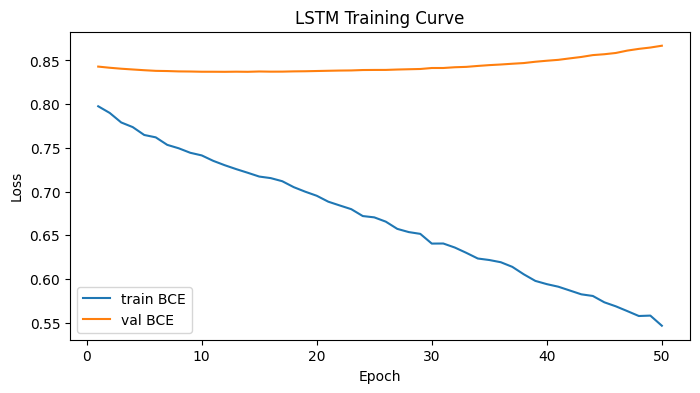

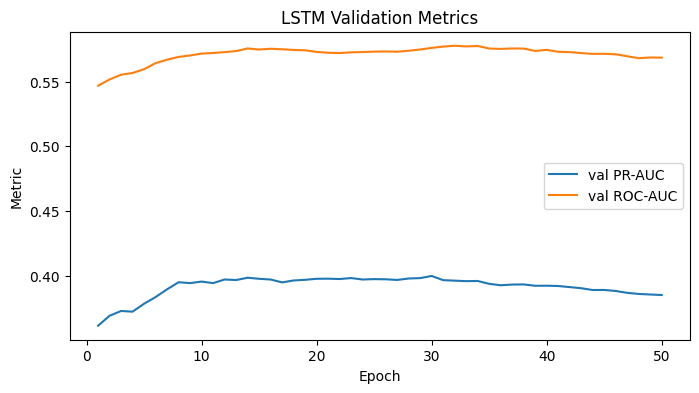

In [333]:
if RUN_LSTM:
    plt.figure(figsize=(8, 4))
    plt.plot(lstm_history["epoch"], lstm_history["train_loss"], label="train BCE")
    plt.plot(lstm_history["epoch"], lstm_history["val_loss"], label="val BCE")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("LSTM Training Curve")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(lstm_history["epoch"], lstm_history["val_pr_auc"], label="val PR-AUC")
    plt.plot(lstm_history["epoch"], lstm_history["val_roc_auc"], label="val ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")

    plt.legend()
    plt.title("LSTM Validation Metrics")
    plt.show()

## 13. Error analysis

This creates a test-set table with predicted probabilities, actual labels, and VIX values. Use this to inspect false positives and false negatives.

,y_true,y_prob,y_pred,error_type
date,,,,
2022-03-10,0,0.521178,1,FP
2022-03-11,0,0.520765,1,FP
2022-03-14,0,0.521275,1,FP
2022-03-15,0,0.522355,1,FP
2022-03-16,0,0.522254,1,FP


,count
error_type,
FP,456
TN,318
TP,207
FN,70


,count,avg_prob,median_prob,min_prob,max_prob
error_type,,,,,
FN,70,0.419490,0.428528,0.347538,0.444945
FP,456,0.487914,0.481581,0.445023,0.580863
TN,318,0.417703,0.422290,0.347436,0.444776
TP,207,0.492154,0.489201,0.446093,0.565521


,y_true,y_prob,y_pred,error_type
date,,,,
2025-05-01,0,0.580863,1,FP
2025-04-30,0,0.579227,1,FP
2025-04-29,0,0.577525,1,FP
2025-05-07,0,0.574811,1,FP
2025-04-28,0,0.574498,1,FP
2025-05-06,0,0.573718,1,FP
2025-05-02,0,0.573197,1,FP
2025-04-25,0,0.573001,1,FP
2025-05-05,0,0.571607,1,FP


False positives: predicted spike, but actual non-spike


,y_true,y_prob,y_pred,error_type
date,,,,
2025-05-01,0,0.580863,1,FP
2025-04-30,0,0.579227,1,FP
2025-04-29,0,0.577525,1,FP
2025-05-07,0,0.574811,1,FP
2025-04-28,0,0.574498,1,FP
2025-05-06,0,0.573718,1,FP
2025-05-02,0,0.573197,1,FP
2025-04-25,0,0.573001,1,FP
2025-05-05,0,0.571607,1,FP


False negatives: actual spike, but model missed it


,y_true,y_prob,y_pred,error_type
date,,,,
2025-09-26,1,0.347538,0,FN
2025-09-29,1,0.347573,0,FN
2025-09-30,1,0.349610,0,FN
2025-10-01,1,0.350241,0,FN
2025-10-02,1,0.370322,0,FN
2025-10-03,1,0.374822,0,FN
2025-10-06,1,0.377272,0,FN
2025-10-07,1,0.381228,0,FN
2025-10-08,1,0.383933,0,FN


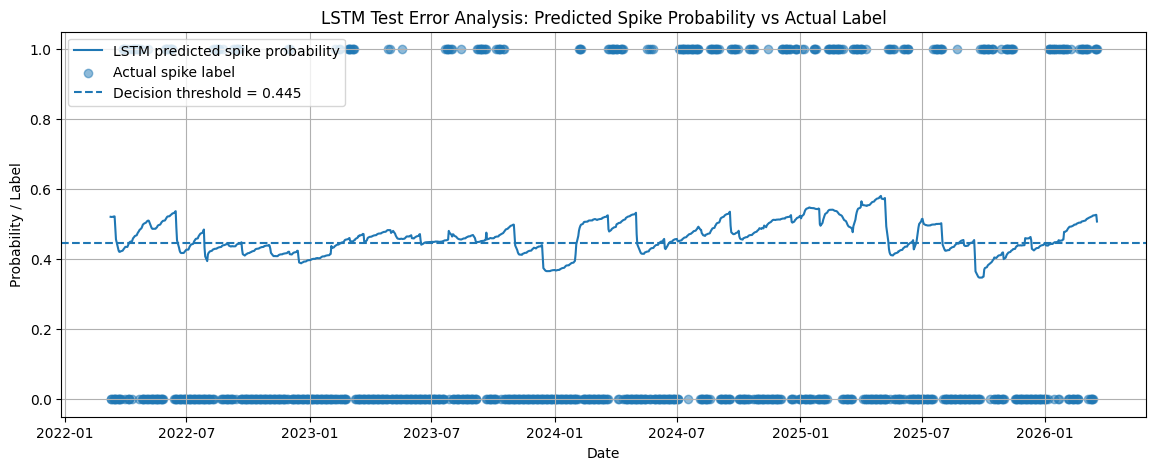

False positives with diagnostics


,y_true,y_prob,y_pred,error_type,^VIX,is_fomc_day
date,,,,,,
2025-05-01,0,0.580863,1,FP,24.600000,0
2025-04-30,0,0.579227,1,FP,24.700001,0
2025-04-29,0,0.577525,1,FP,24.170000,0
2025-05-07,0,0.574811,1,FP,23.549999,1
2025-04-28,0,0.574498,1,FP,25.150000,0
2025-05-06,0,0.573718,1,FP,24.760000,0
2025-05-02,0,0.573197,1,FP,22.680000,0
2025-04-25,0,0.573001,1,FP,24.840000,0
2025-05-05,0,0.571607,1,FP,23.639999,0


False negatives with diagnostics


,y_true,y_prob,y_pred,error_type,^VIX,is_fomc_day
date,,,,,,
2025-09-26,1,0.347538,0,FN,15.290000,0
2025-09-29,1,0.347573,0,FN,16.120001,0
2025-09-30,1,0.349610,0,FN,16.280001,0
2025-10-01,1,0.350241,0,FN,16.290001,0
2025-10-02,1,0.370322,0,FN,16.629999,0
2025-10-03,1,0.374822,0,FN,16.650000,0
2025-10-06,1,0.377272,0,FN,16.370001,0
2025-10-07,1,0.381228,0,FN,17.240000,0
2025-10-08,1,0.383933,0,FN,16.299999,0


In [338]:
# ============================================================
# Error Analysis: LSTM Test Predictions
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Safety checks
required_vars = [
    "lstm_model",
    "test_loader",
    "test_seq_dates",
    "best_t_lstm",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing required variables for LSTM error analysis: {missing}")

# ------------------------------------------------------------
# 1. Get LSTM probabilities on test set
# ------------------------------------------------------------

lstm_model.eval()
device = next(lstm_model.parameters()).device

test_probs_lstm = []
test_true_lstm = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = lstm_model(X_batch)

        if isinstance(logits, tuple):
            logits = logits[0]

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

        test_probs_lstm.extend(probs)
        test_true_lstm.extend(y_batch.detach().cpu().numpy().reshape(-1))

test_probs_lstm = np.asarray(test_probs_lstm)
test_true_lstm = np.asarray(test_true_lstm).astype(int)

# Make sure dates align with sequence outputs
test_seq_dates_lstm = pd.Index(test_seq_dates[-len(test_probs_lstm):])

# ------------------------------------------------------------
# 2. Build test results DataFrame
# ------------------------------------------------------------

test_results_lstm = pd.DataFrame(
    {
        "date": test_seq_dates_lstm,
        "y_true": test_true_lstm,
        "y_prob": test_probs_lstm,
    }
).set_index("date")

test_results_lstm["y_pred"] = (
    test_results_lstm["y_prob"] >= best_t_lstm
).astype(int)

def classify_error(row):
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "TP"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "FP"
    elif row["y_true"] == 1 and row["y_pred"] == 0:
        return "FN"
    else:
        return "TN"

test_results_lstm["error_type"] = test_results_lstm.apply(classify_error, axis=1)

display(test_results_lstm.head())
display(test_results_lstm["error_type"].value_counts())

# ------------------------------------------------------------
# 3. Summary metrics by error type
# ------------------------------------------------------------

summary_lstm = (
    test_results_lstm
    .groupby("error_type")
    .agg(
        count=("y_true", "size"),
        avg_prob=("y_prob", "mean"),
        median_prob=("y_prob", "median"),
        min_prob=("y_prob", "min"),
        max_prob=("y_prob", "max"),
    )
    .sort_index()
)

display(summary_lstm)

# ------------------------------------------------------------
# 4. Top predicted spike probabilities
# ------------------------------------------------------------

top_pred_lstm = test_results_lstm.sort_values("y_prob", ascending=False).head(20)
display(top_pred_lstm)

# ------------------------------------------------------------
# 5. False positives and false negatives
# ------------------------------------------------------------

false_positives_lstm = (
    test_results_lstm[test_results_lstm["error_type"] == "FP"]
    .sort_values("y_prob", ascending=False)
)

false_negatives_lstm = (
    test_results_lstm[test_results_lstm["error_type"] == "FN"]
    .sort_values("y_prob", ascending=True)
)

print("False positives: predicted spike, but actual non-spike")
display(false_positives_lstm.head(20))

print("False negatives: actual spike, but model missed it")
display(false_negatives_lstm.head(20))

# ------------------------------------------------------------
# 6. Plot probability vs actual label
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(test_results_lstm.index, test_results_lstm["y_prob"], label="LSTM predicted spike probability")
plt.scatter(
    test_results_lstm.index,
    test_results_lstm["y_true"],
    label="Actual spike label",
    alpha=0.5,
)
plt.axhline(best_t_lstm, linestyle="--", label=f"Decision threshold = {best_t_lstm:.3f}")
plt.title("LSTM Test Error Analysis: Predicted Spike Probability vs Actual Label")
plt.xlabel("Date")
plt.ylabel("Probability / Label")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 7. Optional: join back selected market features for diagnosis
# ------------------------------------------------------------

diagnostic_cols = [
    "^VIX",
    "vix_ret_1d",
    "vix_ret_5d",
    "vix_z_20d",
    "days_since_fomc",
    "days_to_fomc",
    "is_fomc_day",
]

available_diagnostic_cols = [
    c for c in diagnostic_cols
    if "master" in globals() and c in master.columns
]

if available_diagnostic_cols:
    diagnostic_lstm = test_results_lstm.join(
        master[available_diagnostic_cols],
        how="left"
    )

    print("False positives with diagnostics")
    display(
        diagnostic_lstm[diagnostic_lstm["error_type"] == "FP"]
        .sort_values("y_prob", ascending=False)
        .head(20)
    )

    print("False negatives with diagnostics")
    display(
        diagnostic_lstm[diagnostic_lstm["error_type"] == "FN"]
        .sort_values("y_prob", ascending=True)
        .head(20)
    )
else:
    print("No diagnostic columns found in master. Skipping feature-level error diagnostics.")

## 14. Save outputs

This saves the master dataset, feature matrix, target, and test predictions for later analysis.

In [28]:
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

master.to_parquet(OUTPUT_DIR / "master_with_target.parquet")
X_df.to_parquet(OUTPUT_DIR / "features_raw.parquet")
X_scaled.to_parquet(OUTPUT_DIR / "features_scaled.parquet")
y.to_frame(TARGET_COL).to_parquet(OUTPUT_DIR / "target.parquet")

if RUN_XGBOOST:
    test_results.to_csv(OUTPUT_DIR / "test_predictions_xgboost.csv")

print("Saved outputs to", OUTPUT_DIR)

Saved outputs to /content/drive/MyDrive/OMSCS/Deep_Learning/Final_Project/Code/outputs


## 15. Next data upgrades

The notebook is now structurally clean. The next improvement should be data, not LSTM complexity.

Recommended additions:

- VIX futures term structure: `VX1`, `VX2`, `VX2 - VX1`, `VX1 / VIX`
- Cboe volatility curve: `VIX9D`, `VIX3M`, `VIX6M`, ratios such as `VIX9D / VIX`
- Volatility-of-volatility and skew: `VVIX`, `SKEW`
- SPY/SPX returns, realized volatility, drawdown, intraday range
- Credit stress: HY OAS, IG OAS, NFCI, STLFSI
- Macro calendar flags: CPI, NFP, FOMC, OPEX, VIX expiration